# Plots of three point functions

In [1]:
using Pkg; Pkg.activate(".")
using JLD2, Plots, LaTeXStrings
import Polynomials.fit

  Activating project at `~/Documents/Recherche/projet_these/code/transfer_matrices/TransferMatricesCpp/On_loops_clean/plots`


## CFT prediction

In [2]:
using BarnesDoubleGamma, BootstrapVirasoro
import LinearAlgebra: dot

function Cref(β, ri, si)
    return prod(
        begin
            e = (e1, e2, e3)
            inv(doublegamma( (β+inv(β))/2 + β/2*abs(dot(e, ri)) + inv(β)/2*dot(e, si), β, tol = 1e-8))
        end
        for e1 in (-1, 1) for e2 in (-1, 1) for e3 in (-1, 1)
    )
end

P11(β) = ConformalDimension(CentralCharge(:β, β), :Δ, 0).P

function omega(β, ri, si)
    C123 = Cref(β, ri, si)
    C101 = Cref(β, (ri[1], 0, ri[1]), (si[1], 2*β*P11(β), si[1]))
    C202 = Cref(β, (ri[2], 0, ri[2]), (si[2], 2*β*P11(β), si[2]))
    C303 = Cref(β, (ri[3], 0, ri[3]), (si[3], 2*β*P11(β), si[3]))
    C220 = Cref(β, (ri[2], ri[2], 0), (si[2], si[2], 2*β*P11(β)))
    C000 = Cref(β, (0, 0, 0), (2*β*P11(β), 2*β*P11(β), 2*β*P11(β)))

    C123*sqrt(C000/C101/C303/C202)
end

omega(c::CentralCharge, i1, i2, i3) = omega(abs(c.β), (i1[1], i2[1], i3[1]), (i1[2], i2[2], i3[2]))
omega(s::Symbol, x, i1, i2, i3) = omega(CentralCharge(s, x), i1, i2, i3)

# check that the value is right for percolation
println(isapprox(omega(:β, sqrt(2/3), (1, 0), (1, 0), (1, 0)), 0.9523590967841016697715))

true


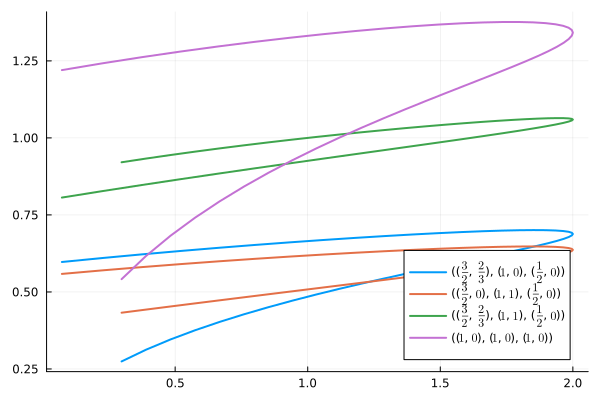

In [3]:
latex_frac(r) = if r%1 == 0 L"%$(Int(r))" else L"\frac{%$(numerator(r))}{%$(denominator(r))}" end
format(r, s) = L"(%$(latex_frac(r)), %$(latex_frac(s)))"

function plot_CFT!(plt, r1, s1, r2, s2, r3, s3)
    βrange = 0.74:0.01:sqrt(1.5)
    nrange = [-2cos(π * β^2) for β in βrange]
    crange = [CentralCharge(β=β) for β in βrange]
    omegas = real.([omega(c, (r1, s1), (r2, s2), (r3, s3)) for c in crange])
    plot!(plt, nrange, omegas, label=L"(%$(format(r1, s1)), %$(format(r2, s2)), %$(format(r3, s3)))", lw=2)
    return plt
end

p = plot()
plot_CFT!(p, 3//2, 2//3, 1, 0, 1//2, 0)
plot_CFT!(p, 3//2, 0, 1, 1, 1//2, 0)
plot_CFT!(p, 3//2, 2//3, 1, 1, 1//2, 0)
plot_CFT!(p, 1, 0, 1, 0, 1, 0)

In [ ]:
plot()
plot_CFT!(p, 2, 1//2, 1, 0, 1, 0)

UndefVarError: UndefVarError: `plot_CFT` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## Lattice results

In [38]:

file(k1, rs1, k2, rs2, k3, rs3) = "../results/run_$k1$(rs1)_$k2$(rs2)_$k3$rs3.jld2"
data(k1, rs1, k2, rs2, k3, rs3) = load(file(k1, rs1, k2, rs2, k3, rs3), "merged")

for var in (:ω, :c123, :c220, :c000, :c101, :c202, :c303)
    nb_values_λ = 16
    λ_min = 0.43
    λ_step = 0.05
    λrange = range(λ_min, step=λ_step, length=nb_values_λ)
    nrange = [-2cos(4λ) for λ in λrange]
    s = String(var)
    @eval begin
        $(var)(k1, rs1, k2, rs2, k3, rs3, L, λ) =
            data(k1, rs1, k2, rs2, k3, rs3)[(L, λ, k1, rs1, k2, rs2, k3, rs3)][$s]
        $(var)(k1, rs1, k2, rs2, k3, rs3, L) = [abs($(var)(k1, rs1, k2, rs2, k3, rs3, L, λ)) for λ in $λrange]
    end
end

function results(k1, rs1, k2, rs2, k3, rs3, L; transform=(ω, L) -> ω)
    transform(ω(k1, rs1, k2, rs2, k3, rs3, L), L)
end

function plot_results!(plt, k1, rs1, k2, rs2, k3, rs3, L; transform=(ω, L) -> ω)
    λrange = range(0.43, step=0.05, length=16)
    nrange = [-2cos(4λ) for λ in λrange]
    plot!(plt, nrange, results(k1, rs1, k2, rs2, k3, rs3, L, transform=transform), label="size $L")
    return plt
end;

function Ωs(k1, rs1, k2, rs2, k3, rs3, λ, Lrange; transform=(Ω, L) -> Ω)
    Dict(
        L => transform(ω(k1, rs1, k2, rs2, k3, rs3, L, λ), L)
        for L in Lrange
    )
end

# assume we have a dict with Ω(L, λ) for L in Lrange
function extrapolateΩ(omegas, Lrange)
    return fit(1 ./ Lrange, [omegas[L] for L in Lrange])
end

function extrapolate_results(r1, s1, r2, s2, r3, s3, Lrange; transform=(ω, L) -> ω)
    k1, k2, k3 = Int.((2r1, 2r2, 2r3))
    rs1, rs2, rs3 = Int.((r1 * s1, r2 * s2, r3 * s3))
    λrange = range(0.43, step=0.05, length=16)
    return [
        extrapolateΩ(Ωs(k1, rs1, k2, rs2, k3, rs3, λ, Lrange, transform=transform), Lrange)(0)
        for λ in λrange
    ]
end

function plot_extrapolation!(plt, extr)
    λrange = range(0.43, step=0.05, length=16)
    nrange = [-2cos(4λ) for λ in λrange]
    scatter!(plt, nrange, extr, label="extrapolation")
end

function plot_extrapolation_λ(r1, s1, r2, s2, r3, s3, λ)
    k1, k2, k3 = Int.((2r1, 2r2, 2r3))
    rs1, rs2, rs3 = Int.((r1 * s1, r2 * s2, r3 * s3))
    Lrange = sort(unique([L for (L, λ, a, b, c, d, e, f) in keys(data(k1, rs1, k2, rs2, k3, rs3))]))
    scatter(1 ./ Lrange, [(Ωs(k1, rs1, k2, rs2, k3, rs3, λ, Lrange))[L] for L in Lrange])
    plot!(0:0.005:0.25, extrapolateΩ(Ωs(k1, rs1, k2, rs2, k3, rs3, λ, Lrange), Lrange).(0:0.005:0.25))
end

function plot_results(r1, s1, r2, s2, r3, s3, Lrange::Vector{Int}; transform=(ω, L) -> ω, cft=false, extrapolate=false)
    k1, k2, k3 = Int.((2r1, 2r2, 2r3))
    rs1, rs2, rs3 = Int.((r1 * s1, r2 * s2, r3 * s3))
    plt = plot(xlabel=L"n", title=L"Ω(%$(format(r1, s1)), %$(format(r2, s2)), %$(format(r3, s3)))")
    for L in Lrange
        plot_results!(plt, k1, rs1, k2, rs2, k3, rs3, L, transform=transform)
    end
    if cft
        plot_CFT!(plt, r1, s1, r2, s2, r3, s3)
    end
    if extrapolate
        extr = extrapolate_results(r1, s1, r2, s2, r3, s3, Lrange; transform=transform)
        plot_extrapolation!(plt, extr)
    end
    return plt
end

function plot_results(r1, s1, r2, s2, r3, s3; transform=(ω, L) -> ω, cft=false, extrapolate=false)
    k1, k2, k3 = Int.((2r1, 2r2, 2r3))
    rs1, rs2, rs3 = Int.((r1 * s1, r2 * s2, r3 * s3))
    Lrange = sort(unique([L for (L, λ, a, b, c, d, e, f) in keys(data(k1, rs1, k2, rs2, k3, rs3))]))
    return plot_results(r1, s1, r2, s2, r3, s3, Lrange, transform=transform, cft=cft, extrapolate=extrapolate)
end


plot_results (generic function with 2 methods)

Results for $(r_1, r_2, r_3) = (\frac32, 2, 1)$, with $s_i=0$, and set positions of the legs.

In [39]:
Lrange = 4:5
λ = 0.43
extrapolateΩ(Ωs(2, 0, 2, 0, 2, 0, λ, Lrange, transform=(Ω, L)->Ω), Lrange)(0)

0.1860523594001938822795828982457096919969264334623702049294287025239403414388395

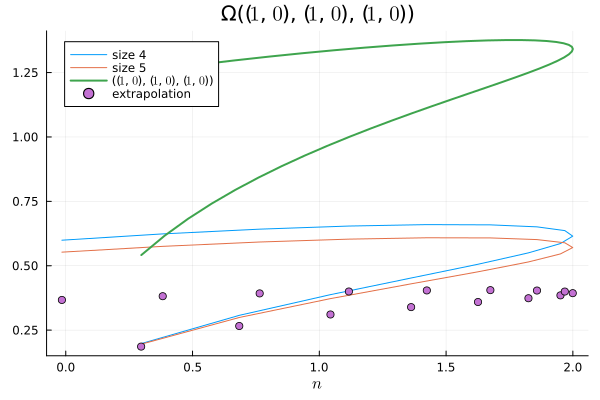

In [40]:
plot_results(1, 0, 1, 0, 1, 0, transform=(ω, L)->ω, cft=true, extrapolate=true)

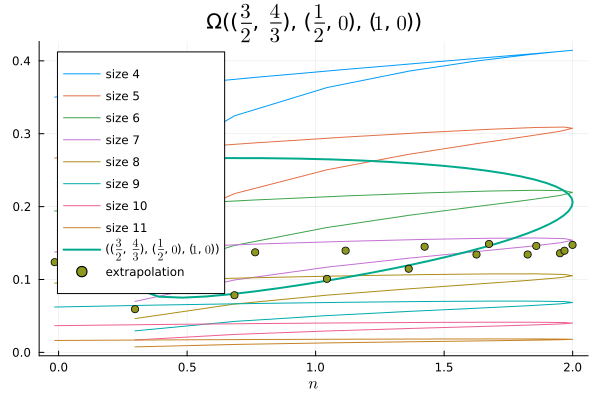

In [41]:
plot_results(3//2, 4//3, 1//2, 0, 1, 0, transform = (Ω, L) -> Ω, cft=true, extrapolate=true)

In [42]:
Ωs(2, 0, 2, 0, 2, 0, 0.63, [4, 5])[5]

0.4764742581786310402357873905301009302342634010308805078829212478513782273081306

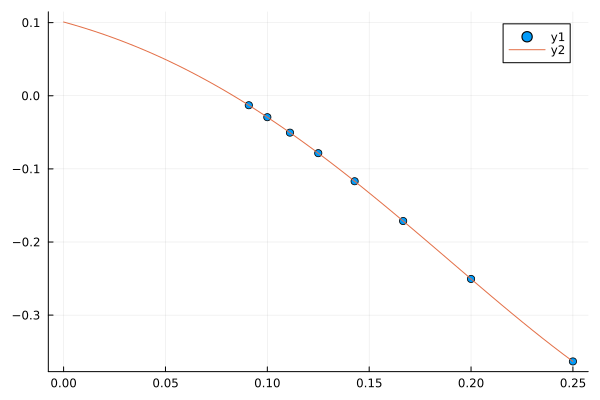

In [44]:
plot_extrapolation_λ(3//2, 4//3, 1//2, 0, 1, 0, 0.53)

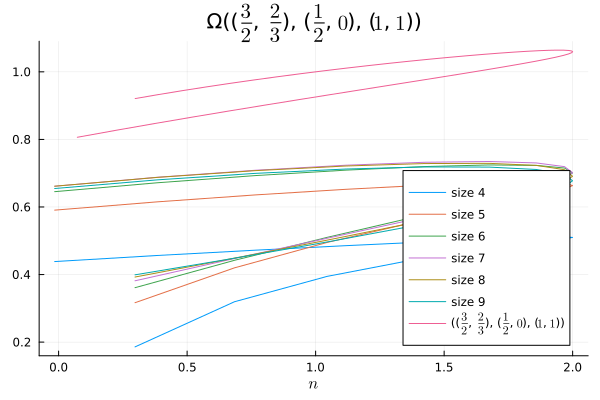

In [52]:
plot_results(3//2, 2//3, 1//2, 0, 1, 1, transform = (Ω, L) -> Ω, cft=true)

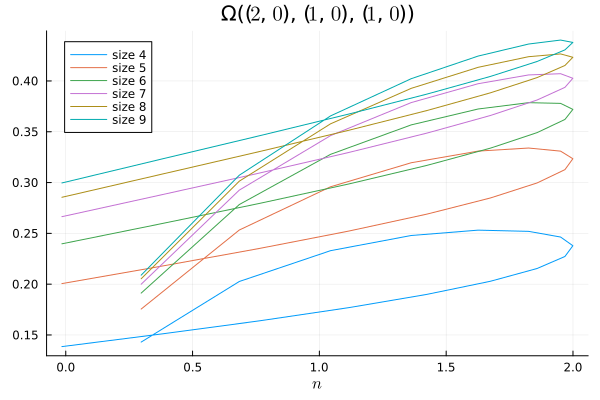

In [40]:
plot_results(2, 0, 1, 0, 1, 0, transform = (Ω, L) -> Ω)

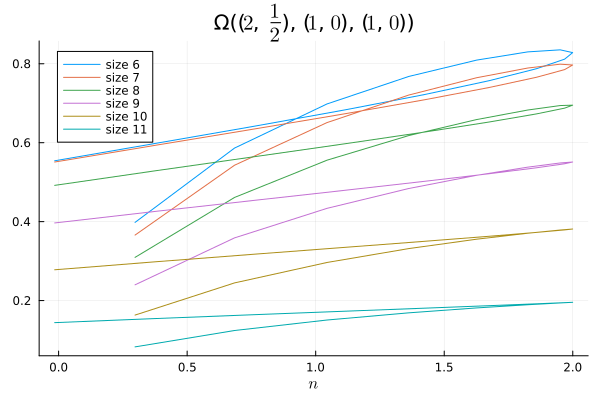

In [57]:
plot_results(2, 1//2, 1, 0, 1, 0, [L for L in 6:11], transform = (Ω, L) -> Ω*L)

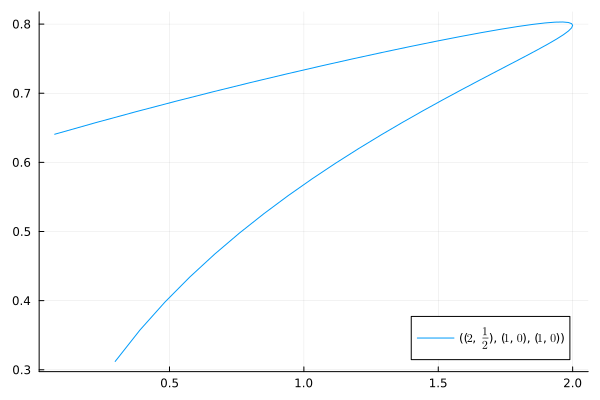

In [58]:
p = plot()
plot_CFT!(p, 2, 1//2, 1, 0, 1, 0)

In [ ]:
load("../results/run_40.jld2", "merged")[(9, 1.18, 3, 0, 1, 0, 2, 1)]

Dict{String, BigFloat} with 7 entries:
  "c000" => 9.02891e+454
  "c123" => 3.1185e+290
  "c220" => 1.88838e+451
  "c101" => 9.44233e+365
  "ω"    => 2.1555e-92
  "c202" => 1.82188e+448
  "c303" => 1.02257e+399